<a href="https://colab.research.google.com/github/liwiaflorkiwicz/EEG_dimensiality_reduction/blob/LDA/LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LDA for EEG dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# read file
data = pd.read_csv('/dataset_A_hands.csv', header = 0)
data.head()
#print(data.shape)

,FC5,FC3,FC1,FCz,FC2,FC4,FC6,C5,C3,C1,...,PO7,PO3,POz,PO4,PO8,O1,Oz,O2,Iz,Label
0,-11.368526,-11.424228,-11.585911,-11.587444,-11.516528,-11.458961,-11.326939,-11.408007,-11.629599,-11.656776,...,-11.226600,-11.357553,-11.381296,-11.238655,-11.062158,-11.126559,-11.223495,-11.151625,-10.948594,Task3
1,-11.284149,-11.422955,-11.369446,-11.320009,-11.390571,-11.411450,-11.411991,-11.402370,-11.569449,-11.696185,...,-10.981480,-11.025114,-11.026598,-11.063468,-11.030770,-10.868531,-10.866038,-10.920515,-10.739326,Task1
2,-11.431263,-11.430120,-11.482541,-11.534096,-11.495824,-11.367992,-11.330367,-11.383096,-11.557855,-11.698244,...,-10.891545,-11.036507,-11.060690,-10.976081,-10.770071,-10.759802,-10.705004,-10.659787,-10.439506,Task2
3,-11.446603,-11.464615,-11.413162,-11.382691,-11.351718,-11.438916,-11.399082,-11.362765,-11.628451,-11.667057,...,-10.949354,-11.032611,-11.052224,-10.937487,-10.974803,-10.871874,-10.841078,-10.876684,-10.661939,Task2
4,-11.467128,-11.599652,-11.588888,-11.570401,-11.589498,-11.433946,-11.456305,-11.366391,-11.675037,-11.676603,...,-11.082195,-11.126224,-11.142371,-11.117976,-10.992686,-10.988595,-11.030893,-11.036307,-10.890251,Task1


## LDA Algorithm

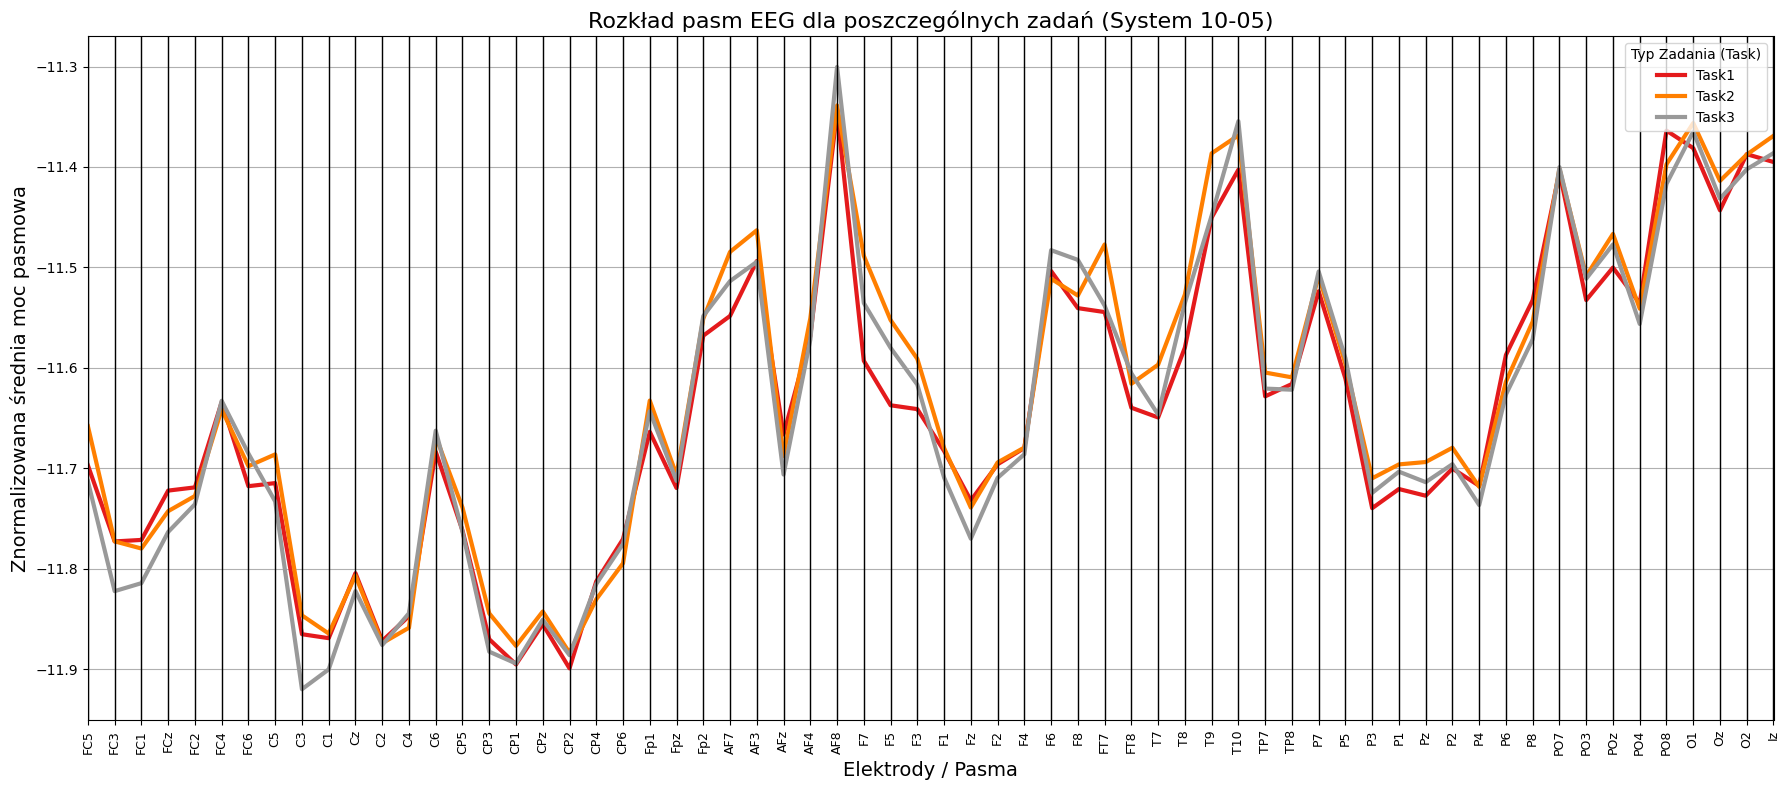

In [ ]:
from pandas.plotting import parallel_coordinates

plt.figure(figsize=(18, 8))

# Wykres uśredniony dla zadań
df_mean = data.groupby('Label').mean().reset_index()
parallel_coordinates(df_mean, class_column='Label', colormap='Set1', linewidth=3.0)

plt.title('Rozkład pasm EEG dla poszczególnych zadań (System 10-05)', fontsize=16)
plt.xlabel('Elektrody / Pasma', fontsize=14)
plt.ylabel('Znormalizowana średnia moc pasmowa', fontsize=14)
plt.xticks(rotation=90, fontsize=9)

plt.legend(title='Typ Zadania (Task)', loc='upper right')

plt.tight_layout()
plt.show()

Visualization

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

X = data.drop(columns=['Label'])
y = data['Label']

# -- StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -- PCA Transformation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PCA df
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Label'] = y.values

# -- LDA transformation
def plot_lda(shrinkage, solver):
  # LDA
  lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrinkage)
  X_lda = lda.fit_transform(X_scaled, y)

  # LDA df
  df_lda = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
  df_lda['Label'] = y.values

  # -- Plotting
  fig, axes = plt.subplots(1, 2, figsize=(16, 6))
  palette = ['#1f77b4', '#ff7f0e', '#2ca02c']

  # PCA
  sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Label', palette=palette,
                  ax=axes[0], s=80, alpha=0.8, edgecolor='k')
  axes[0].set_title('PRZED LDA: Redukcja PCA (brak nadzoru)', fontsize=14)
  axes[0].set_xlabel('PC1')
  axes[0].set_ylabel('PC2')
  axes[0].grid(True, alpha=0.3)

  # LDA
  sns.scatterplot(data=df_lda, x='LD1', y='LD2', hue='Label', palette=palette,
                  ax=axes[1], s=80, alpha=0.8, edgecolor='k')
  axes[1].set_title(f'PO LDA (Solver: {solver}, Shrinkage: {shrinkage})', fontsize=14)
  axes[1].set_xlabel('LD1')
  axes[1].set_ylabel('LD2')
  axes[1].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

Solver: svd    | Shrinkage: None  | Silhouette Score: 0.0494
Solver: eigen  | Shrinkage: auto  | Silhouette Score: 0.0328
Solver: eigen  | Shrinkage: 0.0   | Silhouette Score: 0.0494
Solver: eigen  | Shrinkage: 0.2   | Silhouette Score: 0.0198
Solver: eigen  | Shrinkage: 0.5   | Silhouette Score: 0.0031
Solver: eigen  | Shrinkage: 0.7   | Silhouette Score: -0.0115
Solver: eigen  | Shrinkage: 0.9   | Silhouette Score: -0.0332
--------------------------------------------------
Najlepiej rozdzielone dane dają parametry: {'solver': 'eigen', 'shrinkage': 0.0} (Score: 0.0494)


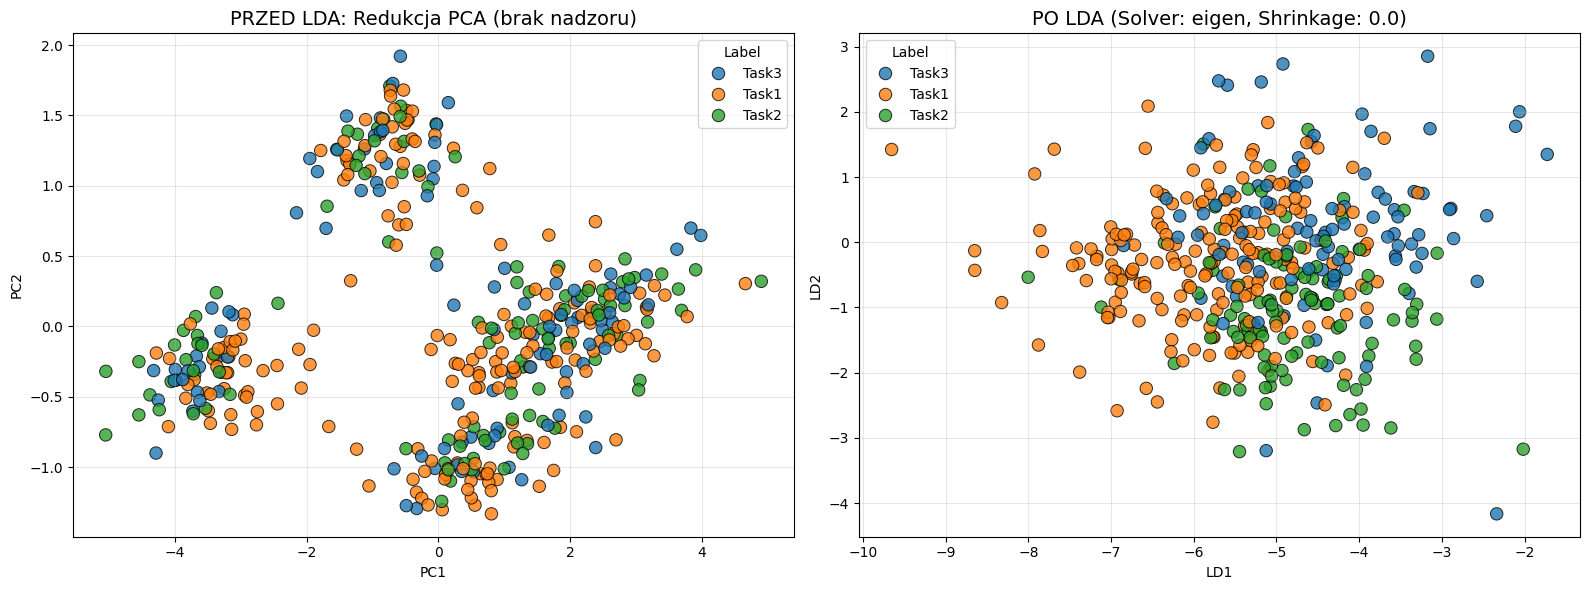

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import silhouette_score

solvers = ['svd', 'eigen']
shrinkages = ['auto', 0.0, 0.2, 0.5, 0.7, 0.9]

best_score = -1
best_params = {}

for solver in solvers:
    current_shrinkages = [None] if solver == 'svd' else shrinkages

    for shrink in current_shrinkages:
        try:
            lda = LinearDiscriminantAnalysis(solver=solver, shrinkage=shrink)
            X_lda_reduced = lda.fit_transform(X, y)

            score = silhouette_score(X_lda_reduced, y)

            print(f"Solver: {solver:<6} | Shrinkage: {str(shrink):<5} | Silhouette Score: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {'solver': solver, 'shrinkage': shrink}

        except Exception as e:
            pass

print("-" * 50)
print(f"Najlepiej rozdzielone dane dają parametry: {best_params} (Score: {best_score:.4f})")

plot_lda(shrinkage=best_params['shrinkage'], solver=best_params['solver'])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# 1. Inicjalizacja i dopasowanie modelu z naszymi najlepszymi parametrami
lda = LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')

# Model musi zostać "nauczony" na danych (używamy fit, nie transform),
# aby wyliczyć wewnętrzne atrybuty takie jak wariancja.
lda.fit(X_scaled, y)

# 2. Wyciągnięcie atrybutu explained_variance_ratio_
# Mnożymy przez 100, aby mieć wygodne procenty zamiast ułamków
variance_ratios = lda.explained_variance_ratio_ * 100

# Tworzymy małą ramkę danych dla biblioteki Seaborn
df_var = pd.DataFrame({
    'Komponent': ['LD1', 'LD2'],
    'Wyjaśniona wariancja (%)': variance_ratios
})

# 3. Rysowanie wykresu (Bar Plot)
plt.figure(figsize=(8, 6))

# Używamy czytelnej palety kolorów, rysujemy słupki z czarnym obramowaniem
ax = sns.barplot(
    data=df_var,
    x='Komponent',
    y='Wyjaśniona wariancja (%)',
    palette='Set2',
    edgecolor='black'
)

# 4. Dodanie dokładnych wartości procentowych nad słupkami
for i, v in enumerate(variance_ratios):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center', fontsize=12, fontweight='bold')

# 5. Formatowanie osi i tytułów
plt.title('Siła dyskryminacyjna komponentów (Explained Variance Ratio)', fontsize=14, pad=15)
plt.xlabel('Komponent (Linear Discriminant)', fontsize=12)
plt.ylabel('Wyjaśniona wariancja (%)', fontsize=12)

# Ustawiamy oś Y twardo od 0 do 100%, aby pokazać właściwą skalę
plt.ylim(0, 100)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Opcjonalnie: Wypisanie wyniku w konsoli
print(f"LD1 wyjaśnia {variance_ratios[0]:.2f}% wariancji (separacji między klasami).")
print(f"LD2 wyjaśnia {variance_ratios[1]:.2f}% wariancji (separacji między klasami).")

LDA as a classificator

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = data.drop(columns=['Label'])
y = data['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lda = LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')
lda.fit(X_train_scaled, y_train)
y_pred = lda.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5185185185185185

Classification Report:
              precision    recall  f1-score   support

       Task1       0.53      0.69      0.60        13
       Task2       0.60      0.43      0.50         7
       Task3       0.40      0.29      0.33         7

    accuracy                           0.52        27
   macro avg       0.51      0.47      0.48        27
weighted avg       0.51      0.52      0.50        27

